In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Weather Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np

weather_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CS-163/4267471.csv")
display(weather_df)

,STATION,NAME,DATE,AWND,PGTM,PRCP,TAVG,TMAX,TMIN,WDF2,WDF5,WSF2,WSF5,WT01,WT02,WT03,WT08
0,USW00023293,"SAN JOSE, CA US",2025-01-01,2.46,1632.0,0.00,50.0,63,38,320.0,340.0,10.1,14.1,NaN,NaN,NaN,NaN
1,USW00023293,"SAN JOSE, CA US",2025-01-02,1.79,1714.0,0.00,53.0,68,45,330.0,360.0,8.1,10.1,NaN,NaN,NaN,NaN
2,USW00023293,"SAN JOSE, CA US",2025-01-03,4.70,1448.0,0.11,55.0,63,49,280.0,290.0,17.0,25.9,NaN,NaN,NaN,NaN
3,USW00023293,"SAN JOSE, CA US",2025-01-04,3.58,1440.0,0.00,52.0,60,44,330.0,330.0,13.0,15.0,NaN,NaN,NaN,NaN
4,USW00023293,"SAN JOSE, CA US",2025-01-05,2.68,1138.0,0.00,52.0,64,43,330.0,320.0,10.1,16.1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,USW00023293,"SAN JOSE, CA US",2026-03-14,6.71,NaN,0.00,NaN,72,48,320.0,360.0,16.1,21.0,NaN,NaN,NaN,NaN
438,USW00023293,"SAN JOSE, CA US",2026-03-15,4.47,NaN,0.00,NaN,80,50,330.0,340.0,14.1,17.9,NaN,NaN,NaN,NaN
439,USW00023293,"SAN JOSE, CA US",2026-03-16,4.03,NaN,0.00,NaN,85,51,310.0,330.0,13.0,17.0,NaN,NaN,NaN,NaN
440,USW00023293,"SAN JOSE, CA US",2026-03-17,2.68,NaN,0.00,NaN,85,56,320.0,340.0,12.1,14.1,NaN,NaN,NaN,NaN


In [ ]:
print(weather_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  442 non-null    object 
 1   NAME     442 non-null    object 
 2   DATE     442 non-null    object 
 3   AWND     425 non-null    float64
 4   PGTM     33 non-null     float64
 5   PRCP     442 non-null    float64
 6   TAVG     420 non-null    float64
 7   TMAX     442 non-null    int64  
 8   TMIN     442 non-null    int64  
 9   WDF2     425 non-null    float64
 10  WDF5     421 non-null    float64
 11  WSF2     425 non-null    float64
 12  WSF5     421 non-null    float64
 13  WT01     27 non-null     float64
 14  WT02     1 non-null      float64
 15  WT03     2 non-null      float64
 16  WT08     16 non-null     float64
dtypes: float64(12), int64(2), object(3)
memory usage: 58.8+ KB
None


In [ ]:
weather_df.describe()

,AWND,PGTM,PRCP,TAVG,TMAX,TMIN,WDF2,WDF5,WSF2,WSF5,WT01,WT02,WT03,WT08
count,425.000000,33.000000,442.000000,420.000000,442.000000,442.000000,425.000000,421.000000,425.000000,421.000000,27.0,1.0,2.0,16.0
mean,6.154800,1386.484848,0.038077,59.102381,70.436652,50.251131,297.035294,284.726841,16.368235,22.172922,1.0,1.0,1.0,1.0
std,2.711948,464.156703,0.152922,7.087014,9.011045,7.554357,65.149763,86.856389,4.768485,7.002709,0.0,NaN,0.0,0.0
min,0.670000,45.000000,0.000000,45.000000,51.000000,33.000000,10.000000,10.000000,6.000000,8.100000,1.0,1.0,1.0,1.0
25%,4.250000,1138.000000,0.000000,53.000000,63.000000,44.000000,310.000000,290.000000,14.100000,17.900000,1.0,1.0,1.0,1.0
50%,6.260000,1508.000000,0.000000,59.500000,70.000000,51.000000,320.000000,320.000000,16.100000,21.900000,1.0,1.0,1.0,1.0
75%,7.610000,1648.000000,0.000000,65.000000,77.000000,56.000000,330.000000,330.000000,19.900000,25.900000,1.0,1.0,1.0,1.0
max,17.000000,2022.000000,1.520000,76.000000,95.000000,69.000000,360.000000,360.000000,33.100000,57.900000,1.0,1.0,1.0,1.0


In [ ]:
main_weather_df = weather_df[["DATE", "PRCP", "TAVG", "TMAX", "TMIN", "WT01", "WT02", "WT03", "WT08"]]
display(main_weather_df)

,DATE,PRCP,TAVG,TMAX,TMIN,WT01,WT02,WT03,WT08
0,2025-01-01,0.00,50.0,63,38,NaN,NaN,NaN,NaN
1,2025-01-02,0.00,53.0,68,45,NaN,NaN,NaN,NaN
2,2025-01-03,0.11,55.0,63,49,NaN,NaN,NaN,NaN
3,2025-01-04,0.00,52.0,60,44,NaN,NaN,NaN,NaN
4,2025-01-05,0.00,52.0,64,43,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
437,2026-03-14,0.00,NaN,72,48,NaN,NaN,NaN,NaN
438,2026-03-15,0.00,NaN,80,50,NaN,NaN,NaN,NaN
439,2026-03-16,0.00,NaN,85,51,NaN,NaN,NaN,NaN
440,2026-03-17,0.00,NaN,85,56,NaN,NaN,NaN,NaN


In [ ]:
cols = ['WT01', 'WT02', 'WT03', 'WT08']
main_weather_df = main_weather_df.fillna(0)
main_weather_df['WT'] = (
    main_weather_df[cols].astype(int)
    .dot(main_weather_df[cols].columns + ', ')
    .str.rstrip(', ')
    .replace('', 'None')
)
main_weather_df = main_weather_df.drop(columns = ['WT01', 'WT02', 'WT03', 'WT08'])
display(main_weather_df)

,DATE,PRCP,TAVG,TMAX,TMIN,WT
0,2025-01-01,0.00,50.0,63,38,None
1,2025-01-02,0.00,53.0,68,45,None
2,2025-01-03,0.11,55.0,63,49,None
3,2025-01-04,0.00,52.0,60,44,None
4,2025-01-05,0.00,52.0,64,43,None
...,...,...,...,...,...,...
437,2026-03-14,0.00,0.0,72,48,None
438,2026-03-15,0.00,0.0,80,50,None
439,2026-03-16,0.00,0.0,85,51,None
440,2026-03-17,0.00,0.0,85,56,None


Weather EDA

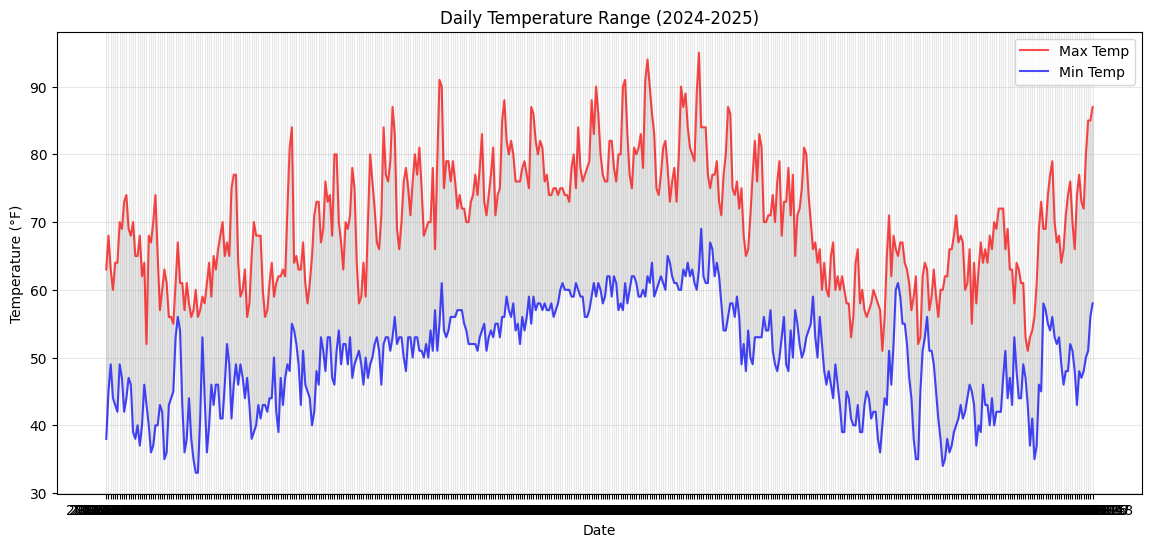

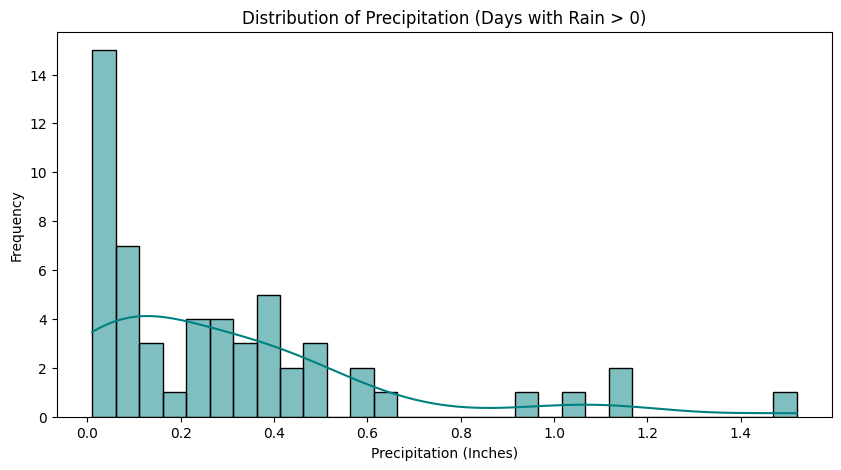

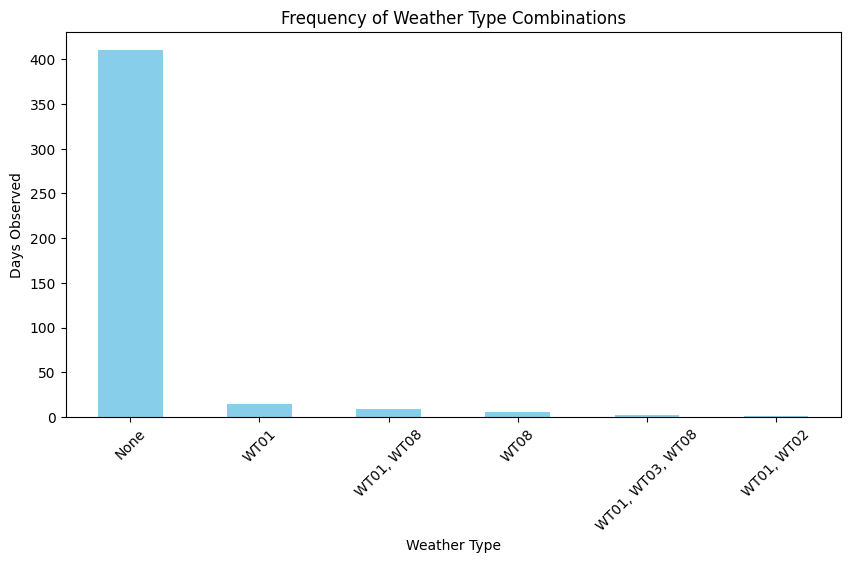

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Temperature Trends Over Time
plt.figure(figsize=(14, 6))
plt.plot(main_weather_df['DATE'], main_weather_df['TMAX'], label='Max Temp', color='red', alpha=0.7)
plt.plot(main_weather_df['DATE'], main_weather_df['TMIN'], label='Min Temp', color='blue', alpha=0.7)
plt.fill_between(main_weather_df['DATE'], main_weather_df['TMIN'], main_weather_df['TMAX'], color='gray', alpha=0.2)
plt.title('Daily Temperature Range (2024-2025)')
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Precipitation Distribution
plt.figure(figsize=(10, 5))
sns.histplot(main_weather_df[main_weather_df['PRCP'] > 0]['PRCP'], bins=30, kde=True, color='teal')
plt.title('Distribution of Precipitation (Days with Rain > 0)')
plt.xlabel('Precipitation (Inches)')
plt.ylabel('Frequency')
plt.show()

# 3. Frequency of Specific Weather Types
wt_counts = main_weather_df['WT'].value_counts()
plt.figure(figsize=(10, 5))
wt_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Weather Type Combinations')
plt.xlabel('Weather Type')
plt.ylabel('Days Observed')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Days with some weather data, most have no weather
sig_weather_days = main_weather_df[(main_weather_df['PRCP'] > 0.5) | (main_weather_df['WT'] != 'None')]
print(f"Number of days with significant weather events: {len(sig_weather_days)}")
display(sig_weather_days.sort_values(by='PRCP', ascending=False).head(10))

Number of days with significant weather events: 38


,DATE,PRCP,TAVG,TMAX,TMIN,WT
285,2025-10-13,1.52,60.0,68,52,None
43,2025-02-13,1.12,55.0,59,53,"WT01, WT08"
368,2026-01-04,1.12,55.0,57,51,None
34,2025-02-04,1.06,57.0,61,43,"WT01, WT08"
411,2026-02-16,0.94,52.0,53,47,None
414,2026-02-19,0.65,47.0,54,41,None
358,2025-12-25,0.61,58.0,63,52,None
316,2025-11-13,0.58,64.0,66,59,None
70,2025-03-12,0.46,56.0,60,43,WT01
42,2025-02-12,0.41,48.0,57,41,WT01


Historical Ridership Data Preprocessing

In [ ]:
historical_ridership_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CS-163/Bus_and_Light_Rail_Average_Ridership_Data_2025.csv')
display(historical_ridership_df)

,Route,F7_1_2005_WK,F8_1_2005_WK,F9_1_2005_WK,F10_1_2005_WK,F11_1_2005_WK,F12_1_2005_WK,F1_1_2006_WK,F2_1_2006_WK,F3_1_2006_WK,...,F6_1_2025_WK,F6_1_2025_SAT,F6_1_2025_SUN,F7_1_2025_WK,F7_1_2025_SAT,F7_1_2025_SUN,F8_1_2025_WK,F8_1_2025_SAT,F8_1_2025_SUN,FID2
0,10.0,1470,1365,1352,1306,1312,1268,1289,1267,1215,...,0.0000,0,0,0.0000,0,0,0.0000,0,0,1
1,85.0,1105,1028,1243,1155,1095,1063,1163,1277,1161,...,111.4286,49,61,106.1364,49,51,109.2857,55,65,2
2,11.0,0,0,0,0,0,0,0,0,0,...,0.0000,0,0,0.0000,0,0,0.0000,0,0,3
3,12.0,0,0,0,0,0,0,0,0,0,...,0.0000,0,0,0.0000,0,0,0.0000,0,0,4
4,13.0,201,222,282,300,266,190,263,287,242,...,0.0000,0,0,0.0000,0,0,0.0000,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,903.0,0,0,0,0,0,0,0,0,0,...,0.0000,0,0,0.0000,0,0,0.0000,0,0,128
128,920.0,0,0,0,0,0,0,0,0,0,...,0.0000,0,0,0.0000,0,0,0.0000,0,0,129
129,NaN,0,0,0,0,0,0,0,0,0,...,4567.8570,3054,1917,5171.0000,2930,4926,5619.0000,4907,5337,130
130,NaN,0,0,0,0,0,0,0,0,0,...,4406.1430,2839,2810,4931.0000,2922,2676,4877.0000,5812,2713,131


In [ ]:
ridership_by_year = {}
for col in historical_ridership_df.columns:
    if '_WK' in col:
        year = int(col.split('_')[-2])
        if year not in ridership_by_year:
            ridership_by_year[year] = []
        ridership_by_year[year].append(col)

annual_ridership = pd.DataFrame({'Route': historical_ridership_df['Route']})
for year, cols in ridership_by_year.items():
    annual_ridership[f'Ridership_{year}'] = historical_ridership_df[cols].sum(axis=1)

display(annual_ridership)

,Route,Ridership_2005,Ridership_2006,Ridership_2007,Ridership_2008,Ridership_2009,Ridership_2010,Ridership_2011,Ridership_2012,Ridership_2013,...,Ridership_2015,Ridership_2016,Ridership_2017,Ridership_2018,Ridership_2019,Ridership_2021,Ridership_2022,Ridership_2023,Ridership_2024,Ridership_2025
0,10.0,8073,16149,16000.0,14262,13606,13564,13181.5,13157,14291,...,16929,15063,13616,12843.7920,11959.0950,0.00000,0.00000,0.00000,0.000,0.0000
1,85.0,6689,13835,12978.0,1000,0,0,0.0,0,0,...,0,0,0,0.0000,0.0000,489.30324,1117.24106,1323.76084,1546.675,891.4199
2,11.0,0,0,0.0,1589,1364,1295,1808.0,900,0,...,0,0,0,0.0000,0.0000,0.00000,0.00000,0.00000,0.000,0.0000
3,12.0,0,0,0.0,0,0,0,0.0,0,0,...,0,0,0,0.0000,0.0000,0.00000,0.00000,0.00000,0.000,0.0000
4,13.0,1461,3023,2798.0,3409,2909,1948,2289.5,2074,2105,...,2151,2205,1874,1690.9962,1571.2381,0.00000,0.00000,0.00000,0.000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,903.0,0,0,0.0,0,0,0,0.0,0,0,...,0,0,0,0.0000,0.0000,0.00000,0.00000,0.00000,0.000,0.0000
128,920.0,0,0,0.0,0,0,0,0.0,0,37,...,0,3,28,28.0000,0.0000,0.00000,0.00000,0.00000,0.000,0.0000
129,NaN,0,0,0.0,0,0,0,0.0,0,0,...,0,0,0,0.0000,0.0000,10947.14300,51969.72500,63662.57700,67376.131,40612.4590
130,NaN,0,0,0.0,0,0,0,0.0,0,0,...,0,0,0,0.0000,0.0000,8306.33300,38257.44800,48449.93800,55906.903,34592.7000


In [ ]:
display(historical_ridership_df.tail(5))

,Route,F7_1_2005_WK,F8_1_2005_WK,F9_1_2005_WK,F10_1_2005_WK,F11_1_2005_WK,F12_1_2005_WK,F1_1_2006_WK,F2_1_2006_WK,F3_1_2006_WK,...,F6_1_2025_WK,F6_1_2025_SAT,F6_1_2025_SUN,F7_1_2025_WK,F7_1_2025_SAT,F7_1_2025_SUN,F8_1_2025_WK,F8_1_2025_SAT,F8_1_2025_SUN,FID2
127,903.0,0,0,0,0,0,0,0,0,0,...,0.000,0,0,0.0,0,0,0.0,0,0,128
128,920.0,0,0,0,0,0,0,0,0,0,...,0.000,0,0,0.0,0,0,0.0,0,0,129
129,NaN,0,0,0,0,0,0,0,0,0,...,4567.857,3054,1917,5171.0,2930,4926,5619.0,4907,5337,130
130,NaN,0,0,0,0,0,0,0,0,0,...,4406.143,2839,2810,4931.0,2922,2676,4877.0,5812,2713,131
131,NaN,0,0,0,0,0,0,0,0,0,...,4574.905,2629,3627,5838.0,2434,2196,4808.0,6546,2422,132


Ridership by Stop Data Preprocessing

In [ ]:
rbs_full_df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/CS-163/OCT_2024_RBS_FULL_DATA_SET.XLSX')
rbs_by_stop_df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/CS-163/OCT_2024_RBS_FULL_DATA_SET_BY_STOP_FINAL.xlsx')

print("--- OCT_2024_RBS_FULL_DATA_SET ---")
print(f"Shape: {rbs_full_df.shape}")

print("\n--- OCT_2024_RBS_FULL_DATA_SET_BY_STOP_FINAL ---")
print(f"Shape: {rbs_by_stop_df.shape}")

--- OCT_2024_RBS_FULL_DATA_SET ---
Shape: (380135, 32)

--- OCT_2024_RBS_FULL_DATA_SET_BY_STOP_FINAL ---
Shape: (3202, 7)


In [ ]:
# Display all columns of the full dataset to verify it contains raw passenger data
print("All columns in rbs_full_df:")
for col in rbs_full_df.columns:
    print(f"- {col}")

All columns in rbs_full_df:
- ROUTE_NAME
- ROUTE_REV
- ROUTE_NUMBER
- SERVICE_PERIOD
- SERVICE_CODE
- SERVICE_CODE2
- DIRECTION_NAME
- BRANCH
- TRIP_TIME
- SORT_ORDER
- STOP_ID
- MAIN_CROSS_STREET
- BOARDINGS
- ALIGHTINGS
- TRIPS
- AVG_BOARDINGS
- AVG_ALIGHTINGS
- AVG_ACTIVITY
- PASS_LOAD
- PEAK_LOAD
- AVG_PEAK_LOAD
- CITY
- STOP_KEY
- Stop_ID_Text
- Stop_ID_Num
- Stop_ID_REV
- STOP_DISPLAY
- Additional_Notes
- PATTERN_KEY
- BLOCK
- TOTAL_SORT
- SORT_SP


In [ ]:
# Check for missing values and data types in the stop-level dataset
print("Missing values per column:")
display(rbs_by_stop_df.isnull().sum())

# Summary statistics for numerical activity columns
display(rbs_by_stop_df.describe())

Missing values per column:


,0
Stop_ID_Num,5
SERVICE_PERIOD,5
MAIN_CROSS_STREET,5
ROUTES_SERVED,5
AVG_BOARDINGS,5
AVG_ALIGHTINGS,5
AVG_ACTIVITY,5


,Stop_ID_Num,AVG_BOARDINGS,AVG_ALIGHTINGS,AVG_ACTIVITY
count,3197.000000,3197.000000,3197.000000,3197.000000
mean,62728.350328,32.243595,32.434250,64.678252
std,1686.873625,78.483628,79.305339,142.227139
min,60001.000000,0.000000,0.000000,0.000000
25%,61156.000000,2.382989,2.500937,6.328044
50%,62726.000000,8.521731,9.198899,20.747261
75%,63913.000000,28.891727,29.563420,62.423000
max,66068.000000,1895.943569,1921.008186,3440.434792


Ridership EDA

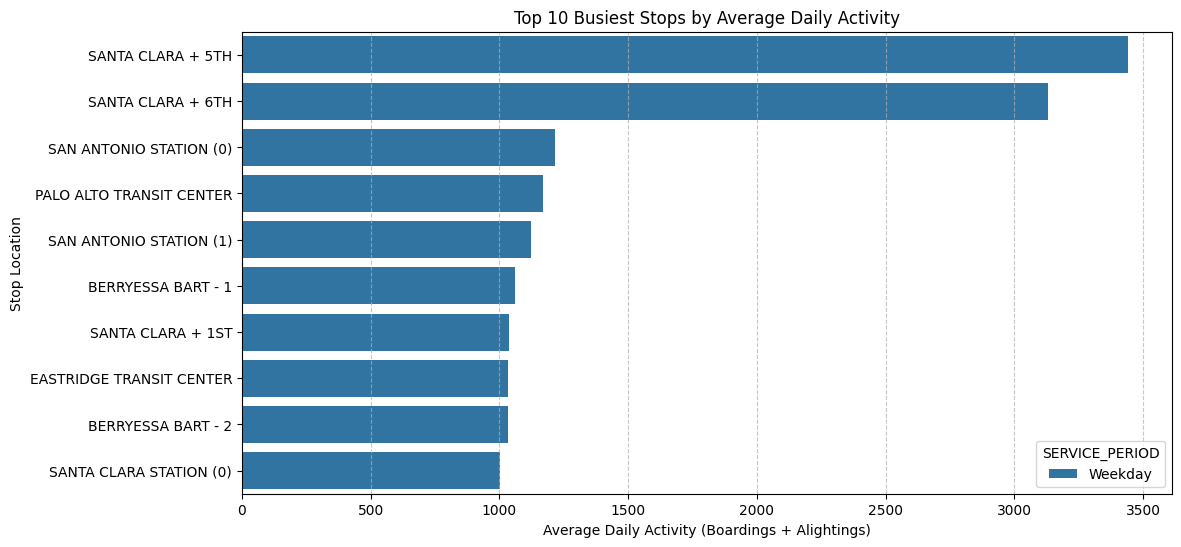

In [ ]:
top_stops = rbs_by_stop_df.nlargest(10, 'AVG_ACTIVITY')

plt.figure(figsize=(12, 6))
sns.barplot(data=top_stops, x='AVG_ACTIVITY', y='MAIN_CROSS_STREET', hue='SERVICE_PERIOD')
plt.title('Top 10 Busiest Stops by Average Daily Activity')
plt.xlabel('Average Daily Activity (Boardings + Alightings)')
plt.ylabel('Stop Location')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

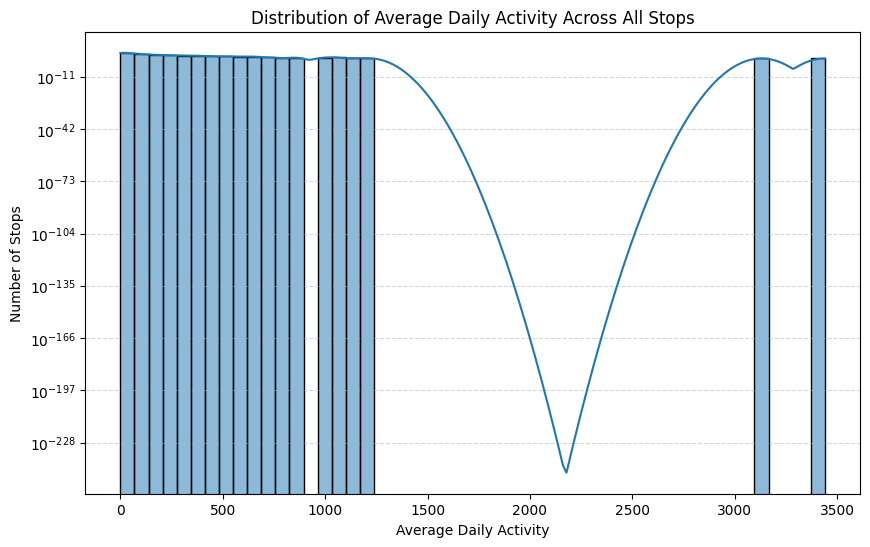

Number of 'Super Hub' stops (>3 SD from mean): 54


,MAIN_CROSS_STREET,AVG_ACTIVITY,SERVICE_PERIOD
233,SANTA CLARA + 5TH,3440.434792,Weekday
214,SANTA CLARA + 6TH,3131.212201,Weekday
2706,SAN ANTONIO STATION (0),1216.886195,Weekday
310,PALO ALTO TRANSIT CENTER,1167.923886,Weekday
2733,SAN ANTONIO STATION (1),1124.617839,Weekday
3059,BERRYESSA BART - 1,1060.224181,Weekday
213,SANTA CLARA + 1ST,1037.175818,Weekday
3034,EASTRIDGE TRANSIT CENTER,1034.420274,Weekday
3058,BERRYESSA BART - 2,1033.615294,Weekday
2707,SANTA CLARA STATION (0),1003.396827,Weekday


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(rbs_by_stop_df['AVG_ACTIVITY'].dropna(), bins=50, kde=True)
plt.title('Distribution of Average Daily Activity Across All Stops')
plt.xlabel('Average Daily Activity')
plt.ylabel('Number of Stops')
plt.yscale('log') # Remember for scale, high stops will drown out otherwise
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Identify Stops with very signifigant difference in activity (3 sds higher than mean)
mean_act = rbs_by_stop_df['AVG_ACTIVITY'].mean()
std_act = rbs_by_stop_df['AVG_ACTIVITY'].std()
super_hubs = rbs_by_stop_df[rbs_by_stop_df['AVG_ACTIVITY'] > (mean_act + 3 * std_act)]

print(f"Number of 'Super Hub' stops (>3 SD from mean): {len(super_hubs)}")
display(super_hubs[['MAIN_CROSS_STREET', 'AVG_ACTIVITY', 'SERVICE_PERIOD']].sort_values(by='AVG_ACTIVITY', ascending=False).head(10))

Temporal Analysis: Peak Hours and Ridership Trends

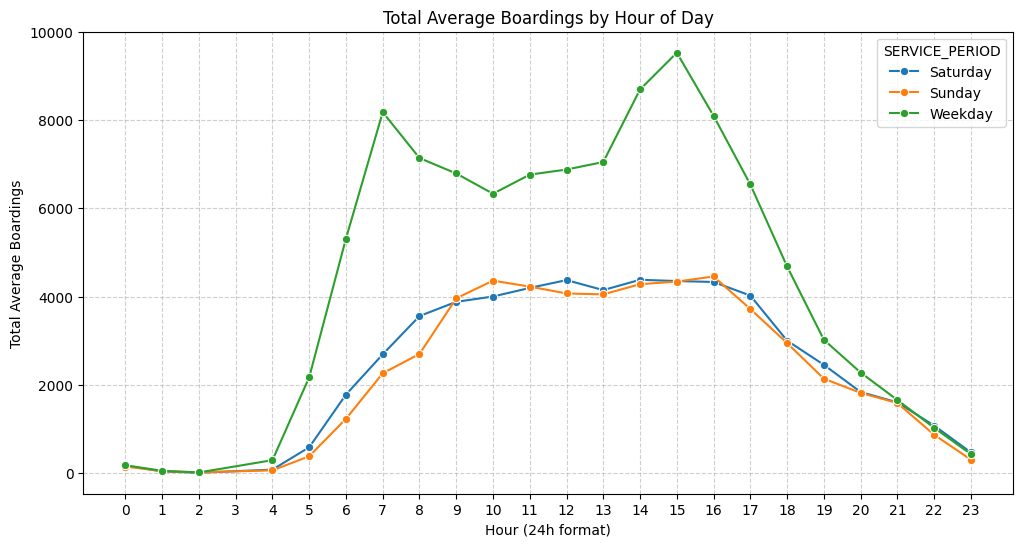

In [ ]:
# Convert TRIP_TIME to a manageable format (extracting hour)
rbs_full_df['HOUR'] = pd.to_datetime(rbs_full_df['TRIP_TIME'], format='%H:%M:%S', errors='coerce').dt.hour

# Group by Hour and Service Period to see the distribution
hourly_ridership = rbs_full_df.groupby(['HOUR', 'SERVICE_PERIOD'])['AVG_BOARDINGS'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_ridership, x='HOUR', y='AVG_BOARDINGS', hue='SERVICE_PERIOD', marker='o')
plt.title('Total Average Boardings by Hour of Day')
plt.xlabel('Hour (24h format)')
plt.ylabel('Total Average Boardings')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Communities of Concern Data Preprocessing

In [ ]:
coc_df = pd.read_csv('/content/communities_of_concern_2020_acs2018_-1910075097215603691.csv')

print("Communities of Concern (GIS Data) Columns:")
print(coc_df.columns)
display(coc_df.head())

# Check if transit data has spatial components we can map
print("\nTransit Stop Data Columns:")
print(rbs_by_stop_df.columns)

Communities of Concern (GIS Data) Columns:
Index(['objectid', 'Geographic ID', 'State FIPS', 'County FIPS',
       'Census Tract', 'Total Population', 'Total Population for Income',
       'Total Civilian Population', 'Total Households', 'Total Families',
       'Total Over 5 Population', 'Total Over 75 Population',
       'People of Color Population', 'Single-Parent Family Population',
       'Limited English Proficiency Population', 'Low-Income Population',
       'Disabled Population', 'Rent-Burdened Population',
       'Zero-Vehicle Household Population', 'Percent Over 75',
       'Percent People of Color', 'Percent Single-Parent Family',
       'Percent Limited English Proficiency', 'Percent Low-Income',
       'Percent Disabled', 'Percent Rent-Burdened',
       'Percent Zero-Vehicle Household', 'Over 75 Reg Mean Plus Half SD',
       'People of Color Reg Mean Plus Half SD',
       'Single-Parent Family Reg Mean Plus Half SD',
       'Limited English Proficiency Reg Mean Plus Half

,objectid,Geographic ID,State FIPS,County FIPS,Census Tract,Total Population,Total Population for Income,Total Civilian Population,Total Households,Total Families,...,Disabled Reg Mean Plus Half SD,Rent-Burdened Reg Mean Plus Half SD,Zero-Vehicle Household Reg Mean Plus Half SD,PBA 2035 Equity Priority Community,PBA 2040 Equity Priority Community,PBA 2050 Equity Priority Community,Change PBA 2040 to 2050,Equity Priority Community Class,Shape__Area,Shape__Length
0,1601,6001401000,6,1,401000,6024,6016,6016,2439,1159,...,1,1,1,1,1,1,0,High,0.000117,0.044945
1,1604,6001401300,6,1,401300,3855,3563,3563,1804,457,...,1,1,1,1,1,1,0,Higher,0.000088,0.041021
2,1605,6001401400,6,1,401400,4331,4331,4331,1576,623,...,1,1,1,1,1,1,0,Highest,0.000077,0.039114
3,1606,6001401500,6,1,401500,2663,2663,2663,1080,432,...,1,1,1,1,1,1,0,Highest,0.000048,0.029823
4,1607,6001401600,6,1,401600,2269,2269,2269,868,341,...,1,1,1,1,1,1,0,Higher,0.000065,0.038322



Transit Stop Data Columns:
Index(['Stop_ID_Num', 'SERVICE_PERIOD', 'MAIN_CROSS_STREET', 'ROUTES_SERVED',
       'AVG_BOARDINGS', 'AVG_ALIGHTINGS', 'AVG_ACTIVITY'],
      dtype='object')


In [ ]:
# Check for any spatial or geographic columns in the full dataset
print("Columns in rbs_full_df:")
print(rbs_full_df.columns)

# Also check if the COC dataset has county or city info to narrow down to San Jose
print("\nUnique County FIPS in coc_df:")
print(coc_df['County FIPS'].unique())

# Sample unique cities in transit data if available
if 'CITY' in rbs_full_df.columns:
    print("\nUnique Cities in Transit Data:")
    print(rbs_full_df['CITY'].unique())

Columns in rbs_full_df:
Index(['ROUTE_NAME', 'ROUTE_REV', 'ROUTE_NUMBER', 'SERVICE_PERIOD',
       'SERVICE_CODE', 'SERVICE_CODE2', 'DIRECTION_NAME', 'BRANCH',
       'TRIP_TIME', 'SORT_ORDER', 'STOP_ID', 'MAIN_CROSS_STREET', 'BOARDINGS',
       'ALIGHTINGS', 'TRIPS', 'AVG_BOARDINGS', 'AVG_ALIGHTINGS',
       'AVG_ACTIVITY', 'PASS_LOAD', 'PEAK_LOAD', 'AVG_PEAK_LOAD', 'CITY',
       'STOP_KEY', 'Stop_ID_Text', 'Stop_ID_Num', 'Stop_ID_REV',
       'STOP_DISPLAY', 'Additional_Notes', 'PATTERN_KEY', 'BLOCK',
       'TOTAL_SORT', 'SORT_SP', 'HOUR'],
      dtype='object')

Unique County FIPS in coc_df:
[ 1 13 41 55 75 81 85 95 97]

Unique Cities in Transit Data:
['Santa Clara' 'San Jose' 'Morgan Hill' 'County of Santa Clara' 'Gilroy'
 'Palo Alto' 'Los Altos' 'Mountain View' 'Sunnyvale' nan 'Los Altos Hills'
 'Cupertino' 'Saratoga' 'Campbell' 'Los Gatos' 'Milpitas' 'SAN JOSE'
 'Federal Government' 'Monte Sereno' 'CAMPBELL']


Communities of Concern EDA

/tmp/ipykernel_1470/3414527998.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sc_coc, x='Equity Priority Community Class', order=['Highest', 'Higher', 'High', 'Low'], palette='viridis')
/tmp/ipykernel_1470/3414527998.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_activity.sort_values('AVG_ACTIVITY', ascending=False).head(10), x='AVG_ACTIVITY', y='CITY', palette='magma')


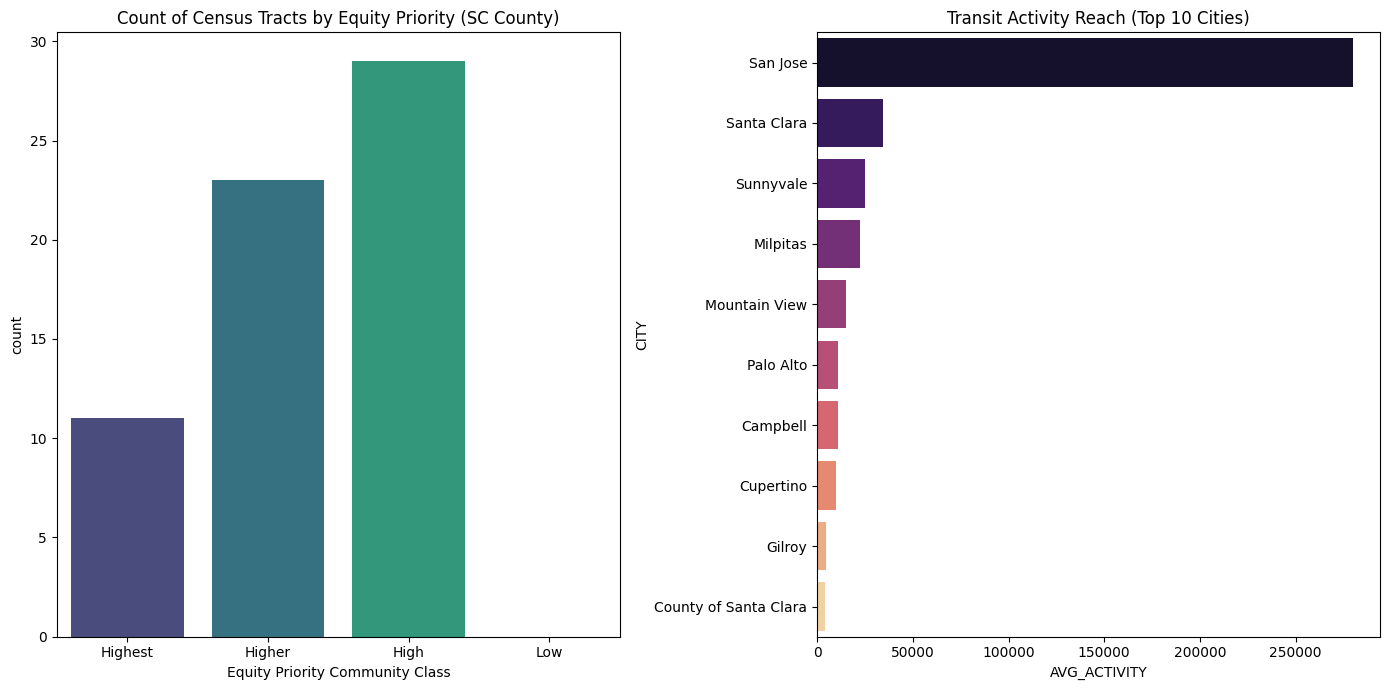

Total Census Tracts in SC County COC data: 63


In [ ]:
# Filter COC for Santa Clara County (FIPS 85)
sc_coc = coc_df[coc_df['County FIPS'] == 85].copy()

city_activity = rbs_full_df.groupby('CITY')['AVG_ACTIVITY'].sum().reset_index()

plt.figure(figsize=(14, 7))

# Subplot 1: Distribution of Equity Priority Classes in Santa Clara County
plt.subplot(1, 2, 1)
sns.countplot(data=sc_coc, x='Equity Priority Community Class', order=['Highest', 'Higher', 'High', 'Low'], palette='viridis')
plt.title('Count of Census Tracts by Equity Priority (SC County)')

# Subplot 2: Transit Reach - Top Cities by Activity
plt.subplot(1, 2, 2)
sns.barplot(data=city_activity.sort_values('AVG_ACTIVITY', ascending=False).head(10), x='AVG_ACTIVITY', y='CITY', palette='magma')
plt.title('Transit Activity Reach (Top 10 Cities)')

plt.tight_layout()
plt.show()

print(f"Total Census Tracts in SC County COC data: {len(sc_coc)}")